# Tiny-p Exact Solvers: equal-budget methodology comparison

This notebook keeps two exact-DP examples (one per new solver), each with tiny exact p-value near `10^-7`.
It compares **IID sampling, MCMC-IS, and SAMC** under the **same total step budget** per method.

It also includes two additional exact-tractable scenarios with clearly different statistic distributions:
- binary outcomes with exact hypergeometric tail
- nonlinear numeric values with exact linear-statistic DP

Method focus:
- `RankSumDPSolver`: rank-based (Mann-Whitney U / rank-sum)
- `LinearStatisticDPSolver`: numeric linear statistics (e.g., difference in means)


In [1]:
from pathlib import Path
import sys
from math import comb
import json
import time

import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from perm_pval.core.problem import PermutationTestProblem
from perm_pval.stats.two_sample import difference_in_means
from perm_pval.stats.ranks import mann_whitney_u
from perm_pval.exact.rank_sum_dp import RankSumDPSolver
from perm_pval.exact.linear_statistic_dp import LinearStatisticDPSolver
from perm_pval.methods.random_sampling import run_random_sampling
from perm_pval.methods.mcmc_is import run_mcmc_is
from perm_pval.methods.samc import run_samc
from perm_pval.methods.beta_tuning import (
    estimate_scale_T,
    iid_pilot_statistics,
    init_beta_from_iid_pilot,
    make_short_chain_q_runner,
    tune_beta_to_target_q,
)

print(f"Using project root: {project_root}")


Using project root: /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS


## Simulation Controls (edit here)

This notebook now supports a quick mode and a full mode:
- `FAST_MODE=True`: feasible turnaround for iteration
- `FAST_MODE=False`: large-budget runs (can be very slow)

Fairness rule for method comparison:
- IID, MCMC-IS, and SAMC get the same total budget (`TOTAL_STEPS_PER_METHOD`).


In [12]:
# ---- Runtime preset ----
FAST_MODE = True

if FAST_MODE:
    TOTAL_STEPS_PER_METHOD = 200_000
    N_REPEATS = 4
    PILOT_IID_SAMPLES = 8_000
    TUNE_STEPS = 5_000
    TUNE_BURN_IN = 1_000
    DIST_PLOT_SAMPLES = 12_000
    BETA_SWEEP_TOTAL_STEPS = 120_000
    BETA_SWEEP_REPEATS = 3
else:
    TOTAL_STEPS_PER_METHOD = 1_000_000
    N_REPEATS = 6
    PILOT_IID_SAMPLES = 20_000
    TUNE_STEPS = 12_000
    TUNE_BURN_IN = 2_000
    DIST_PLOT_SAMPLES = 30_000
    BETA_SWEEP_TOTAL_STEPS = 300_000
    BETA_SWEEP_REPEATS = 4

BOXPLOT_SCENARIO = "rank"  # "rank" or "linear"
SEED_RANK = 31
SEED_LINEAR = 41
SEED_BOXPLOT_BASE = 101
SEED_BETA_SWEEP_BASE = 701

# ---- Equal total budget per method ----
IID_SAMPLES = TOTAL_STEPS_PER_METHOD

MCMC_CHAINS = 2
MCMC_STEPS_PER_CHAIN = max(TOTAL_STEPS_PER_METHOD // MCMC_CHAINS, 1)
MCMC_TOTAL_STEPS = MCMC_STEPS_PER_CHAIN * MCMC_CHAINS
MCMC_BURN_IN = min(int(0.20 * MCMC_STEPS_PER_CHAIN), max(MCMC_STEPS_PER_CHAIN - 1, 0))
MCMC_THIN = 1

SAMC_STEPS = TOTAL_STEPS_PER_METHOD
SAMC_BURN_IN = int(0.20 * SAMC_STEPS)
SAMC_N_BINS = 40
SAMC_T0 = 10_000.0
SAMC_TRACE_EVERY = 2_000

# ---- Beta initialization + tuning controls ----
PILOT_SCALE_METHOD = "sd"  # "sd" or "mad"
P0_DESIGN = 1e-8
D_ALPHA = 0.25
USE_TRUE_P0_FOR_Q_TARGET = True  # if exact p is known in simulation, use p0=exact_p
Q_TARGET_DESIGN = P0_DESIGN ** D_ALPHA
BETA_MAX_INIT = 1e6

TUNE_THIN = 2
TUNE_BRACKET_FACTOR = 2.0
TUNE_TOL_REL = 0.20
TUNE_MAX_BRACKET_ITERS = 12
TUNE_MAX_BISECT_ITERS = 12
TUNE_REPLICATES = 1
TUNE_REUSE_STATE = True

# Optional override for debugging (None = use tuned beta)
BETA_OVERRIDE = None

# MCMC-IS OBM variance estimation
MCMC_ESTIMATE_VARIANCE = True
MCMC_OBM_BATCH_SIZE = None

# ---- Beta sweep diagnostics controls ----
BETA_SWEEP_MULTIPLIERS = [0.01, 0.25, 0.6, 0.85, 1.0, 1.2, 1.5, 2]
BETA_SWEEP_CHAINS = 2
BETA_SWEEP_BURN_IN_FRAC = 0.20
BETA_SWEEP_THIN = 1

print({
    "FAST_MODE": FAST_MODE,
    "TOTAL_STEPS_PER_METHOD": TOTAL_STEPS_PER_METHOD,
    "N_REPEATS": N_REPEATS,
    "BOXPLOT_SCENARIO": BOXPLOT_SCENARIO,
    "IID_SAMPLES": IID_SAMPLES,
    "MCMC_CHAINS": MCMC_CHAINS,
    "MCMC_STEPS_PER_CHAIN": MCMC_STEPS_PER_CHAIN,
    "MCMC_TOTAL_STEPS": MCMC_TOTAL_STEPS,
    "MCMC_BURN_IN": MCMC_BURN_IN,
    "SAMC_STEPS": SAMC_STEPS,
    "SAMC_BURN_IN": SAMC_BURN_IN,
    "PILOT_IID_SAMPLES": PILOT_IID_SAMPLES,
    "TUNE_STEPS": TUNE_STEPS,
    "TUNE_BURN_IN": TUNE_BURN_IN,
    "Q_TARGET_DESIGN": Q_TARGET_DESIGN,
    "USE_TRUE_P0_FOR_Q_TARGET": USE_TRUE_P0_FOR_Q_TARGET,
    "MCMC_ESTIMATE_VARIANCE": MCMC_ESTIMATE_VARIANCE,
    "BETA_SWEEP_TOTAL_STEPS": BETA_SWEEP_TOTAL_STEPS,
    "BETA_SWEEP_REPEATS": BETA_SWEEP_REPEATS,
    "BETA_SWEEP_MULTIPLIERS": BETA_SWEEP_MULTIPLIERS,
})


{'FAST_MODE': True, 'TOTAL_STEPS_PER_METHOD': 200000, 'N_REPEATS': 4, 'BOXPLOT_SCENARIO': 'rank', 'IID_SAMPLES': 200000, 'MCMC_CHAINS': 2, 'MCMC_STEPS_PER_CHAIN': 100000, 'MCMC_TOTAL_STEPS': 200000, 'MCMC_BURN_IN': 20000, 'SAMC_STEPS': 200000, 'SAMC_BURN_IN': 40000, 'PILOT_IID_SAMPLES': 8000, 'TUNE_STEPS': 5000, 'TUNE_BURN_IN': 1000, 'Q_TARGET': 0.01, 'MCMC_ESTIMATE_VARIANCE': True, 'BETA_SWEEP_TOTAL_STEPS': 120000, 'BETA_SWEEP_REPEATS': 3, 'BETA_SWEEP_MULTIPLIERS': [0.01, 0.25, 0.6, 0.85, 1.0, 1.2, 1.5, 2]}


## Helpers

This section includes:
1. Tiny-p near-tail synthetic case
2. Beta workflow (pilot scale + Laplace init + short-chain tuning)
3. Equal-budget comparison runner for IID, MCMC-IS, SAMC
4. Repeated-run boxplot utility with progress logging
5. Beta-sweep diagnostics utility for MCMC-IS (`beta`, `q`, variance estimate, ESS, acceptance)
6. Hypergeometric exact-tail helper for binary outcomes


In [3]:
def near_tail_labels_tiny_p_case() -> tuple[np.ndarray, np.ndarray, int, int]:
    """
    Construct a near-tail (not-max) configuration with tiny exact p-value (~1e-7)
    and many tail states.

    Values are 1..40, treated size 20, treated set {1,16,23,...,40}.
    This yields exact right-tail p = 11642 / C(40,20) = 8.4456e-08.
    """
    n = 40
    n_treated = 20
    x = np.arange(1, n + 1, dtype=float)
    treated_values = set([1, 16] + list(range(23, 41)))
    y = np.array([1 if int(v) in treated_values else 0 for v in x], dtype=np.int8)
    return x, y, n, n_treated


def beta_from_p_formula(p: float) -> float:
    """Requested start rule: beta0 = sqrt(log(1/p))."""
    if not (0.0 < p < 1.0):
        raise ValueError("p must satisfy 0 < p < 1")
    return float(np.sqrt(np.log(1.0 / p)))


def sample_uniform_statistics(
    problem: PermutationTestProblem,
    n_samples: int,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    vals = np.empty(n_samples, dtype=float)
    for i in range(n_samples):
        y = problem.sample_uniform_labels(rng)
        vals[i] = problem.compute_stat(y)
    return vals


def build_beta_workflow(
    problem: PermutationTestProblem,
    exact_p: float,
    *,
    seed: int,
) -> dict:
    p0_for_qtarget = float(exact_p) if USE_TRUE_P0_FOR_Q_TARGET else float(P0_DESIGN)
    q_target = float(p0_for_qtarget ** D_ALPHA)

    pilot_t = iid_pilot_statistics(problem, n_samples=PILOT_IID_SAMPLES, seed=seed)
    sigma_t = estimate_scale_T(pilot_t, method=PILOT_SCALE_METHOD)

    beta_formula = beta_from_p_formula(exact_p)
    beta0_laplace = init_beta_from_iid_pilot(
        pilot_T=pilot_t,
        T_obs=problem.t_obs,
        sigma_T=sigma_t,
        p0=p0_for_qtarget,
        q_target=q_target,
        beta_max=BETA_MAX_INIT,
    )

    runner = make_short_chain_q_runner(
        problem,
        sigma_T=sigma_t,
        thin=TUNE_THIN,
        seed=seed + 1,
    )
    tuning = tune_beta_to_target_q(
        run_short_chain_fn=runner,
        init_state=problem.y_obs,
        beta0=beta0_laplace,
        q_target=q_target,
        n_steps=TUNE_STEPS,
        burn_in=TUNE_BURN_IN,
        bracket_factor=TUNE_BRACKET_FACTOR,
        tol_rel=TUNE_TOL_REL,
        max_bracket_iter=TUNE_MAX_BRACKET_ITERS,
        max_bisect_iter=TUNE_MAX_BISECT_ITERS,
        replicate=TUNE_REPLICATES,
        reuse_state=TUNE_REUSE_STATE,
    )

    beta_used = float(BETA_OVERRIDE) if BETA_OVERRIDE is not None else float(tuning["beta_hat"])

    return {
        "beta_formula_sqrt_log_1_over_p": beta_formula,
        "beta0_laplace": float(beta0_laplace),
        "beta_hat_tuned": float(tuning["beta_hat"]),
        "beta_used": beta_used,
        "sigma_t": float(sigma_t),
        "p0_design": float(P0_DESIGN),
        "p0_for_qtarget": float(p0_for_qtarget),
        "use_true_p0_for_qtarget": bool(USE_TRUE_P0_FOR_Q_TARGET),
        "d_alpha": float(D_ALPHA),
        "q_target": float(q_target),
        "q_hat_at_beta_hat": float(tuning["q_hat"]),
        "bracket_succeeded": bool(tuning["bracket_succeeded"]),
        "tol_used": float(tuning["tol_used"]),
        "history_len": len(tuning["history"]),
        "history_tail": tuning["history"][-5:],
        "beta_override": BETA_OVERRIDE,
    }


def samc_variance_proxy(result) -> float:
    """
    Rough variance proxy for SAMC estimate.

    This uses Bernoulli variance p(1-p)/n_eff with n_eff = post-burn-in steps.
    It ignores dependence and SAMC reweighting effects, so interpret as a coarse scale indicator.
    """
    n_eff = max(int(result.n_steps - result.burn_in), 1)
    p = float(result.estimate)
    return float(max(p * (1.0 - p) / n_eff, 0.0))


def compare_methodologies(
    problem: PermutationTestProblem,
    exact_p: float,
    *,
    seed: int,
    beta_workflow: dict | None = None,
) -> tuple[dict, np.ndarray, object, object, dict]:
    if beta_workflow is None:
        beta_workflow = build_beta_workflow(problem, exact_p, seed=seed + 10)

    rs = run_random_sampling(problem, n_samples=IID_SAMPLES, seed=seed)

    mcmc = run_mcmc_is(
        problem,
        beta=beta_workflow["beta_used"],
        sigma_t=beta_workflow["sigma_t"],
        n_steps=MCMC_STEPS_PER_CHAIN,
        burn_in=MCMC_BURN_IN,
        thin=MCMC_THIN,
        n_chains=MCMC_CHAINS,
        seed=seed + 1,
        init="random",
        estimate_variance=MCMC_ESTIMATE_VARIANCE,
        obm_batch_size=MCMC_OBM_BATCH_SIZE,
    )

    samc = run_samc(
        problem,
        n_steps=SAMC_STEPS,
        burn_in=SAMC_BURN_IN,
        n_bins=SAMC_N_BINS,
        t0=SAMC_T0,
        seed=seed + 2,
        init="random",
        trace_every=SAMC_TRACE_EVERY,
    )

    t_uniform = sample_uniform_statistics(problem, n_samples=DIST_PLOT_SAMPLES, seed=seed + 3)

    summary = {
        "exact_dp": exact_p,
        "iid_sampling": {
            "estimate": rs.estimate,
            "variance_estimate": float(rs.standard_error ** 2),
            "tail_hits": rs.tail_hits,
            "tail_share": rs.estimate,
            "n_samples": rs.n_samples,
        },
        "mcmc_is": {
            "estimate": mcmc.estimate,
            "variance_estimate": getattr(mcmc, "snis_variance_obm", None),
            "tail_hits_raw_sample": getattr(mcmc, "tail_hits_weighted_sample", None),
            "tail_share_raw_sample": getattr(mcmc, "tail_share_raw_sample", None),
            "snis_mcse_obm": getattr(mcmc, "snis_mcse_obm", None),
            "ess": mcmc.ess,
            "acceptance_rate": mcmc.overall_acceptance_rate,
            "n_weighted_samples": mcmc.n_weighted_samples,
            "beta": beta_workflow["beta_used"],
            "sigma_t": beta_workflow["sigma_t"],
            "total_steps": MCMC_TOTAL_STEPS,
        },
        "samc": {
            "estimate": samc.estimate,
            "variance_estimate": samc_variance_proxy(samc),
            "acceptance_rate": samc.acceptance_rate,
            "n_steps": samc.n_steps,
            "burn_in": samc.burn_in,
            "visitation_l1_error": float(np.sum(np.abs(samc.visitation_frequency - samc.target_visitation))),
        },
        "beta_workflow": beta_workflow,
        "equal_budget": {
            "iid_samples": IID_SAMPLES,
            "mcmc_total_steps": MCMC_TOTAL_STEPS,
            "samc_steps": SAMC_STEPS,
        },
    }
    return summary, t_uniform, mcmc, samc, beta_workflow


def run_repeated_boxplot_study(
    problem: PermutationTestProblem,
    exact_p: float,
    *,
    scenario_name: str,
    seed_base: int,
    verbose: bool = True,
) -> dict:
    beta_workflow = build_beta_workflow(problem, exact_p, seed=seed_base + 1000)

    method_labels = ["IID", "MCMC-IS", "SAMC"]
    est = {k: [] for k in method_labels}
    var = {k: [] for k in method_labels}

    t_all_start = time.perf_counter()
    for r in range(N_REPEATS):
        t_rep_start = time.perf_counter()
        seed = seed_base + 10 * r
        summary, _, _, _, _ = compare_methodologies(
            problem,
            exact_p,
            seed=seed,
            beta_workflow=beta_workflow,
        )
        est["IID"].append(summary["iid_sampling"]["estimate"])
        est["MCMC-IS"].append(summary["mcmc_is"]["estimate"])
        est["SAMC"].append(summary["samc"]["estimate"])

        var["IID"].append(summary["iid_sampling"]["variance_estimate"])
        var["MCMC-IS"].append(summary["mcmc_is"]["variance_estimate"])
        var["SAMC"].append(summary["samc"]["variance_estimate"])

        if verbose:
            dt = time.perf_counter() - t_rep_start
            print(f"[{scenario_name}] repeat {r+1}/{N_REPEATS} done in {dt:.1f}s")

    if verbose:
        dt_all = time.perf_counter() - t_all_start
        print(f"[{scenario_name}] total boxplot study time: {dt_all/60.0:.1f} min")

    floor = 1e-300
    est_log = [np.log10(np.maximum(np.asarray(est[k], dtype=float), floor)) for k in method_labels]

    var_log = []
    for k in method_labels:
        v = np.asarray(var[k], dtype=float)
        v = v[np.isfinite(v) & (v > 0.0)]
        if v.size == 0:
            v = np.array([np.nan], dtype=float)
        var_log.append(np.log10(v))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    axes[0].boxplot(est_log, tick_labels=method_labels, showfliers=False)
    axes[0].axhline(np.log10(exact_p), color="black", linestyle="--", linewidth=1.4, label="log10 exact")
    axes[0].set_title(f"{scenario_name}: estimator distribution")
    axes[0].set_ylabel("log10(estimate)")
    axes[0].legend()

    axes[1].boxplot(var_log, tick_labels=method_labels, showfliers=False)
    axes[1].set_title(f"{scenario_name}: estimated variance distribution")
    axes[1].set_ylabel("log10(estimated variance)")

    plt.tight_layout()
    plt.show()

    summary_table = {}
    for k in method_labels:
        arr = np.asarray(est[k], dtype=float)
        summary_table[k] = {
            "mean_estimate": float(np.mean(arr)),
            "median_estimate": float(np.median(arr)),
            "std_estimate": float(np.std(arr)),
            "mean_log10_estimate": float(np.mean(np.log10(np.maximum(arr, floor)))),
        }

    return {
        "scenario": scenario_name,
        "exact_p": float(exact_p),
        "beta_workflow": beta_workflow,
        "equal_budget": {
            "iid_samples": IID_SAMPLES,
            "mcmc_total_steps": MCMC_TOTAL_STEPS,
            "samc_steps": SAMC_STEPS,
        },
        "method_summary": summary_table,
        "estimates": est,
        "variance_estimates": var,
    }


def run_beta_diagnostics_sweep(
    problem: PermutationTestProblem,
    exact_p: float,
    *,
    beta_center: float,
    sigma_t: float,
    seed_base: int,
    beta_multipliers: list[float],
    n_repeats: int,
    total_steps: int,
    n_chains: int,
    burn_in_frac: float,
    thin: int,
    estimate_variance: bool,
    obm_batch_size: int | None,
    verbose: bool = True,
) -> dict:
    if beta_center <= 0.0:
        raise ValueError("beta_center must be positive.")
    if sigma_t <= 0.0:
        raise ValueError("sigma_t must be positive.")
    if n_repeats <= 0:
        raise ValueError("n_repeats must be positive.")
    if total_steps <= 0:
        raise ValueError("total_steps must be positive.")
    if n_chains <= 0:
        raise ValueError("n_chains must be positive.")
    if thin <= 0:
        raise ValueError("thin must be positive.")

    steps_per_chain = max(total_steps // n_chains, 1)
    total_steps_eff = steps_per_chain * n_chains
    burn_in = min(int(burn_in_frac * steps_per_chain), max(steps_per_chain - 1, 0))

    rows: list[dict] = []
    t_start = time.perf_counter()

    for i, mult in enumerate(beta_multipliers):
        beta = float(beta_center * float(mult))
        for r in range(n_repeats):
            seed = seed_base + 1000 * i + 10 * r
            res = run_mcmc_is(
                problem,
                beta=beta,
                sigma_t=sigma_t,
                n_steps=steps_per_chain,
                burn_in=burn_in,
                thin=thin,
                n_chains=n_chains,
                seed=seed,
                init="random",
                estimate_variance=estimate_variance,
                obm_batch_size=obm_batch_size,
            )

            est = float(res.estimate)
            q_hat = float(getattr(res, "tail_share_raw_sample", np.nan))
            var_hat = getattr(res, "snis_variance_obm", np.nan)
            if var_hat is None:
                var_hat = np.nan

            rows.append({
                "beta_multiplier": float(mult),
                "beta": beta,
                "repeat": int(r),
                "seed": int(seed),
                "estimate": est,
                "abs_log10_error": float(abs(np.log10(max(est, 1e-300)) - np.log10(exact_p))),
                "q_tilt_tail_share": q_hat,
                "variance_estimate": float(var_hat) if np.isfinite(var_hat) else np.nan,
                "mcse_estimate": float(getattr(res, "snis_mcse_obm", np.nan)) if getattr(res, "snis_mcse_obm", np.nan) is not None else np.nan,
                "ess": float(res.ess),
                "acceptance_rate": float(res.overall_acceptance_rate),
                "tail_hits_raw_sample": int(getattr(res, "tail_hits_weighted_sample", 0)),
                "n_weighted_samples": int(res.n_weighted_samples),
                "weight_cv": float(getattr(res.weight_summary, "cv", np.nan)),
            })

            if verbose:
                print(
                    f"[beta sweep] mult={mult:.3g} repeat {r+1}/{n_repeats} "
                    f"q={q_hat:.4e} p_hat={est:.4e} ess={res.ess:.1f} acc={res.overall_acceptance_rate:.3f}"
                )

    summary = []
    unique_betas = sorted({row["beta"] for row in rows})
    for beta in unique_betas:
        sub = [row for row in rows if row["beta"] == beta]
        q = np.asarray([row["q_tilt_tail_share"] for row in sub], dtype=float)
        est = np.asarray([row["estimate"] for row in sub], dtype=float)
        var = np.asarray([row["variance_estimate"] for row in sub], dtype=float)
        ess = np.asarray([row["ess"] for row in sub], dtype=float)
        acc = np.asarray([row["acceptance_rate"] for row in sub], dtype=float)
        wcv = np.asarray([row.get("weight_cv", np.nan) for row in sub], dtype=float)
        abs_log10_err = np.asarray([row["abs_log10_error"] for row in sub], dtype=float)
        var_finite = var[np.isfinite(var) & (var > 0.0)]

        mean_est = float(np.mean(est))
        emp_var = float(np.var(est, ddof=1)) if est.size > 1 else float("nan")
        mean_var_hat = float(np.mean(var_finite)) if var_finite.size else float("nan")
        var_calib = float(emp_var / mean_var_hat) if (np.isfinite(emp_var) and np.isfinite(mean_var_hat) and mean_var_hat > 0.0) else float("nan")

        summary.append({
            "beta": float(beta),
            "beta_multiplier": float(beta / beta_center),
            "n_runs": int(est.size),
            "mean_estimate": mean_est,
            "median_estimate": float(np.median(est)),
            "bias": float(mean_est - exact_p),
            "rel_bias": float((mean_est - exact_p) / exact_p),
            "rmse": float(np.sqrt(np.mean((est - exact_p) ** 2))),
            "mean_abs_log10_error": float(np.mean(abs_log10_err)),
            "mean_variance_estimate": mean_var_hat,
            "empirical_var": emp_var,
            "var_calibration_ratio": var_calib,
            "mean_q_tilt_tail_share": float(np.mean(q)),
            "mean_ess": float(np.mean(ess)),
            "mean_acceptance_rate": float(np.mean(acc)),
            "mean_weight_cv": float(np.nanmean(wcv)) if np.any(np.isfinite(wcv)) else float("nan"),
        })

    if verbose:
        dt = time.perf_counter() - t_start
        print(f"[beta sweep] total time: {dt/60.0:.1f} min")

    return {
        "rows": rows,
        "summary": summary,
        "settings": {
            "total_steps": int(total_steps_eff),
            "steps_per_chain": int(steps_per_chain),
            "n_chains": int(n_chains),
            "burn_in": int(burn_in),
            "thin": int(thin),
            "n_repeats": int(n_repeats),
            "beta_center": float(beta_center),
            "sigma_t": float(sigma_t),
            "beta_multipliers": [float(v) for v in beta_multipliers],
        },
    }


def plot_beta_sweep_diagnostics(beta_sweep: dict, exact_p: float, scenario_name: str) -> None:
    rows = beta_sweep["rows"]
    if not rows:
        raise ValueError("beta_sweep has no rows.")

    betas = sorted({row["beta"] for row in rows})
    labels = [f"{b:.3g}" for b in betas]

    q_data = [np.asarray([r["q_tilt_tail_share"] for r in rows if r["beta"] == b], dtype=float) for b in betas]
    est_data = [np.asarray([r["estimate"] for r in rows if r["beta"] == b], dtype=float) for b in betas]
    var_data = []
    ess_data = [np.asarray([r["ess"] for r in rows if r["beta"] == b], dtype=float) for b in betas]
    acc_data = [np.asarray([r["acceptance_rate"] for r in rows if r["beta"] == b], dtype=float) for b in betas]
    wcv_data = [np.asarray([r.get("weight_cv", np.nan) for r in rows if r["beta"] == b], dtype=float) for b in betas]

    for b in betas:
        v = np.asarray([r["variance_estimate"] for r in rows if r["beta"] == b], dtype=float)
        v = v[np.isfinite(v) & (v > 0.0)]
        if v.size == 0:
            v = np.array([np.nan], dtype=float)
        var_data.append(v)

    floor = 1e-300
    est_log = [np.log10(np.maximum(v, floor)) for v in est_data]
    var_log = [np.log10(v) for v in var_data]

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))

    axes[0, 0].boxplot(q_data, tick_tick_labels=labels, showfliers=False)
    axes[0, 0].set_title("Tilted-tail occupancy q")
    axes[0, 0].set_xlabel("beta")
    axes[0, 0].set_ylabel("q_hat = P_pi_beta(T >= T_obs)")

    axes[0, 1].boxplot(est_log, tick_tick_labels=labels, showfliers=False)
    axes[0, 1].axhline(np.log10(exact_p), color="black", linestyle="--", linewidth=1.2, label="log10 exact")
    axes[0, 1].set_title("Estimator across beta")
    axes[0, 1].set_xlabel("beta")
    axes[0, 1].set_ylabel("log10(p_hat)")
    axes[0, 1].legend()

    axes[0, 2].boxplot(var_log, tick_tick_labels=labels, showfliers=False)
    axes[0, 2].set_title("Estimated variance across beta")
    axes[0, 2].set_xlabel("beta")
    axes[0, 2].set_ylabel("log10(var_hat)")

    axes[1, 0].boxplot(ess_data, tick_tick_labels=labels, showfliers=False)
    axes[1, 0].set_title("ESS across beta")
    axes[1, 0].set_xlabel("beta")
    axes[1, 0].set_ylabel("ESS")

    axes[1, 1].boxplot(acc_data, tick_tick_labels=labels, showfliers=False)
    axes[1, 1].set_title("Acceptance across beta")
    axes[1, 1].set_xlabel("beta")
    axes[1, 1].set_ylabel("acceptance rate")

    axes[1, 2].boxplot(wcv_data, tick_tick_labels=labels, showfliers=False)
    axes[1, 2].set_title("Weight CV across beta")
    axes[1, 2].set_xlabel("beta")
    axes[1, 2].set_ylabel("CV(weights)")

    fig.suptitle(f"{scenario_name}: MCMC-IS beta diagnostics", fontsize=13)
    plt.tight_layout()
    plt.show()



def treated_successes(x: np.ndarray, y: np.ndarray) -> float:
    """Count successes in treated group for binary outcomes x in {0,1}."""
    x_arr = np.asarray(x, dtype=np.int8)
    y_arr = np.asarray(y, dtype=np.int8)
    return float(int(np.dot(x_arr, y_arr)))


def exact_hypergeom_right_tail(n: int, n_treated: int, total_successes: int, k_obs: int) -> tuple[float, int, int]:
    """
    Exact right-tail probability for treated-success count under random label permutations.

    K ~ Hypergeometric(N=n, K=total_successes, n=n_treated).
    Returns (p_right, tail_hits_count, total_states).
    """
    if not (0 <= total_successes <= n):
        raise ValueError("total_successes must satisfy 0 <= total_successes <= n")
    if not (0 <= n_treated <= n):
        raise ValueError("n_treated must satisfy 0 <= n_treated <= n")
    if not (0 <= k_obs <= n_treated):
        raise ValueError("k_obs must satisfy 0 <= k_obs <= n_treated")

    total_states = comb(n, n_treated)
    k_max = min(total_successes, n_treated)
    k_min = max(0, n_treated - (n - total_successes))

    tail_hits = 0
    for k in range(max(k_obs, k_min), k_max + 1):
        tail_hits += comb(total_successes, k) * comb(n - total_successes, n_treated - k)

    return float(tail_hits / total_states), int(tail_hits), int(total_states)


## Example A: `RankSumDPSolver` (Mann-Whitney U), tiny exact p-value

Large-`n` near-tail case (`n=40`, `n1=20`) with tiny p-value but many tail states.
Exact right-tail probability is `11642 / C(40,20) = 8.4456e-08`.


In [4]:
x_rank, y_rank, n, n_treated = near_tail_labels_tiny_p_case()

rank_problem = PermutationTestProblem(
    X=x_rank,
    y_obs=y_rank,
    statistic=mann_whitney_u,
    tail="right",
)

rank_exact = RankSumDPSolver(rank_problem, statistic_type="u").compute()

print("Rank-sum DP exact p-value:", rank_exact.p_value)
print("Tail hits / permutations:", rank_exact.tail_hits, "/", rank_exact.n_permutations)
print("Tail states count (should be many):", rank_exact.tail_hits)


Rank-sum DP exact p-value: 8.445624347350904e-08
Tail hits / permutations: 11642 / 137846528820
Tail states count (should be many): 11642


In [5]:
rank_beta = build_beta_workflow(rank_problem, rank_exact.p_value, seed=SEED_RANK + 100)
rank_cmp, rank_t_uniform, rank_mcmc, rank_samc, _ = compare_methodologies(
    rank_problem,
    rank_exact.p_value,
    seed=SEED_RANK,
    beta_workflow=rank_beta,
)

print("Beta workflow (rank-sum):")
print(json.dumps(rank_beta, indent=2))
print()
print("Single-run method comparison (rank-sum, equal budget):")
print(json.dumps(rank_cmp, indent=2))


Beta workflow (rank-sum):
{
  "beta_formula_sqrt_log_1_over_p": 4.035719547418867,
  "beta0_laplace": 5.41015625,
  "beta_hat_tuned": 4.0576171875,
  "beta_used": 4.0576171875,
  "sigma_t": 36.46286052285344,
  "p0_design": 1e-08,
  "d_alpha": 0.25,
  "q_target": 0.01,
  "q_hat_at_beta_hat": 0.0095,
  "bracket_succeeded": true,
  "tol_used": 0.002,
  "history_len": 4,
  "history_tail": [
    {
      "stage": "init",
      "iter": 0,
      "beta": 5.41015625,
      "q_hat": 0.0335,
      "accept_rate": 0.2778
    },
    {
      "stage": "bracket_down",
      "iter": 1,
      "beta": 2.705078125,
      "q_hat": 0.001,
      "accept_rate": 0.5446
    },
    {
      "stage": "bisect:rep1",
      "iter": 1,
      "beta": 4.0576171875,
      "q_hat": 0.0095,
      "accept_rate": 0.394
    },
    {
      "stage": "bisect",
      "iter": 1,
      "beta": 4.0576171875,
      "q_hat": 0.0095,
      "accept_rate": 0.394
    }
  ],
  "beta_override": null
}

Single-run method comparison (rank-sum,

## Example B: `LinearStatisticDPSolver` (difference in means), tiny exact p-value

Same large near-tail labeling as Example A, now evaluated with a numeric statistic (difference in means).


In [6]:
x_lin, y_lin, _, _ = near_tail_labels_tiny_p_case()

lin_problem = PermutationTestProblem(
    X=x_lin,
    y_obs=y_lin,
    statistic=difference_in_means,
    tail="right",
)

lin_exact = LinearStatisticDPSolver.from_difference_in_means(
    lin_problem,
    score_scale=1,
).compute()

print("Linear-stat DP exact p-value:", lin_exact.p_value)
print("Tail hits / permutations:", lin_exact.tail_hits, "/", lin_exact.n_permutations)
print("Tail states count (should be many):", lin_exact.tail_hits)


Linear-stat DP exact p-value: 8.445624347350904e-08
Tail hits / permutations: 11642 / 137846528820
Tail states count (should be many): 11642


In [7]:
lin_beta = build_beta_workflow(lin_problem, lin_exact.p_value, seed=SEED_LINEAR + 100)
lin_cmp, lin_t_uniform, lin_mcmc, lin_samc, _ = compare_methodologies(
    lin_problem,
    lin_exact.p_value,
    seed=SEED_LINEAR,
    beta_workflow=lin_beta,
)

print("Beta workflow (linear statistic):")
print(json.dumps(lin_beta, indent=2))
print()
print("Single-run method comparison (linear statistic, equal budget):")
print(json.dumps(lin_cmp, indent=2))


Beta workflow (linear statistic):
{
  "beta_formula_sqrt_log_1_over_p": 4.035719547418867,
  "beta0_laplace": 4.9248046875,
  "beta_hat_tuned": 4.102400779724121,
  "beta_used": 4.102400779724121,
  "sigma_t": 3.6825004440685505,
  "p0_design": 1e-08,
  "d_alpha": 0.25,
  "q_target": 0.01,
  "q_hat_at_beta_hat": 0.011,
  "bracket_succeeded": true,
  "tol_used": 0.002,
  "history_len": 20,
  "history_tail": [
    {
      "stage": "bisect",
      "iter": 7,
      "beta": 4.097591400146484,
      "q_hat": 0.0015,
      "accept_rate": 0.367
    },
    {
      "stage": "bisect:rep1",
      "iter": 8,
      "beta": 4.107210159301758,
      "q_hat": 0.015,
      "accept_rate": 0.3794
    },
    {
      "stage": "bisect",
      "iter": 8,
      "beta": 4.107210159301758,
      "q_hat": 0.015,
      "accept_rate": 0.3794
    },
    {
      "stage": "bisect:rep1",
      "iter": 9,
      "beta": 4.102400779724121,
      "q_hat": 0.011,
      "accept_rate": 0.3692
    },
    {
      "stage": "bise

## Why the Two Exact p-values Match

In this synthetic setup (`x = 1..n`), both statistics are monotone transforms of the same subset-sum of treated values under fixed group size:
- rank-sum / U uses treated rank sum (which equals treated value sum here)
- difference in means is an affine transform of that same treated value sum

So for a right-tail test, they induce the same tail event and therefore the same exact p-value.
If you replace `x` with nonlinearly spaced values (not rank-linear), the two tests generally differ.


## Additional exact scenario A: binary outcomes + hypergeometric exact tail

Construct `x_i in {0,1}` with fixed total successes `M`, and use
`T(y) = # successes in treated`.
Under random label permutations with fixed treated size, `T` is exactly hypergeometric.


In [8]:
n_bin = 40
n1_bin = 20
m_success = 15

# Observed labels: first n1 treated
y_bin = np.zeros(n_bin, dtype=np.int8)
y_bin[:n1_bin] = 1

# Binary outcomes: all successes inside treated group in observed assignment
x_bin = np.zeros(n_bin, dtype=np.int8)
x_bin[:m_success] = 1

bin_problem = PermutationTestProblem(
    X=x_bin,
    y_obs=y_bin,
    statistic=treated_successes,
    tail="right",
)

p_hg, hits_hg, total_hg = exact_hypergeom_right_tail(
    n=n_bin,
    n_treated=n1_bin,
    total_successes=int(np.sum(x_bin)),
    k_obs=int(bin_problem.t_obs),
)

# Cross-check using linear DP (same statistic as weighted sum with binary scores)
bin_exact_dp = LinearStatisticDPSolver(
    bin_problem,
    scores=x_bin.astype(float),
    score_scale=1,
    scale=1.0,
    offset=0.0,
).compute()

bin_t_uniform = sample_uniform_statistics(bin_problem, n_samples=20_000, seed=2501)

print(json.dumps({
    "statistic": "treated_successes",
    "t_obs": bin_problem.t_obs,
    "hypergeom_exact_p": p_hg,
    "hypergeom_tail_hits": hits_hg,
    "total_states": total_hg,
    "dp_exact_p": bin_exact_dp.p_value,
    "dp_tail_hits": bin_exact_dp.tail_hits,
}, indent=2))


{
  "statistic": "treated_successes",
  "t_obs": 15.0,
  "hypergeom_exact_p": 3.8542863904376695e-07,
  "hypergeom_tail_hits": 53130,
  "total_states": 137846528820,
  "dp_exact_p": 3.8542863904376695e-07,
  "dp_tail_hits": 53130
}


## Additional exact scenario B: nonlinear numeric values + linear-stat DP

Use nonlinear numeric data (`x_i = i^2`) with the same fixed-size permutation design.
For `T = difference_in_means`, exact p-value is computed by `LinearStatisticDPSolver`.
This is not rank-linear, so it differs from rank-sum behavior.


In [9]:
x_base, y_nl, _, _ = near_tail_labels_tiny_p_case()
x_nl = x_base ** 2

nl_problem_mean = PermutationTestProblem(
    X=x_nl,
    y_obs=y_nl,
    statistic=difference_in_means,
    tail="right",
)

nl_problem_rank = PermutationTestProblem(
    X=x_nl,
    y_obs=y_nl,
    statistic=mann_whitney_u,
    tail="right",
)

nl_exact_linear = LinearStatisticDPSolver.from_difference_in_means(
    nl_problem_mean,
    score_scale=1,
).compute()

nl_exact_rank = RankSumDPSolver(nl_problem_rank, statistic_type="u").compute()

nl_t_uniform_mean = sample_uniform_statistics(nl_problem_mean, n_samples=20_000, seed=2601)
nl_t_uniform_rank = sample_uniform_statistics(nl_problem_rank, n_samples=20_000, seed=2602)

print(json.dumps({
    "x_transform": "i^2",
    "t_obs_diff_means": nl_problem_mean.t_obs,
    "exact_p_diff_means_linear_dp": nl_exact_linear.p_value,
    "tail_hits_diff_means": nl_exact_linear.tail_hits,
    "t_obs_rank_u": nl_problem_rank.t_obs,
    "exact_p_rank_sum_dp": nl_exact_rank.p_value,
    "tail_hits_rank": nl_exact_rank.tail_hits,
}, indent=2))


{
  "x_transform": "i^2",
  "t_obs_diff_means": 753.2,
  "exact_p_diff_means_linear_dp": 8.124977898155825e-09,
  "tail_hits_diff_means": 1120,
  "t_obs_rank_u": 374.0,
  "exact_p_rank_sum_dp": 8.445624347350904e-08,
  "tail_hits_rank": 11642
}


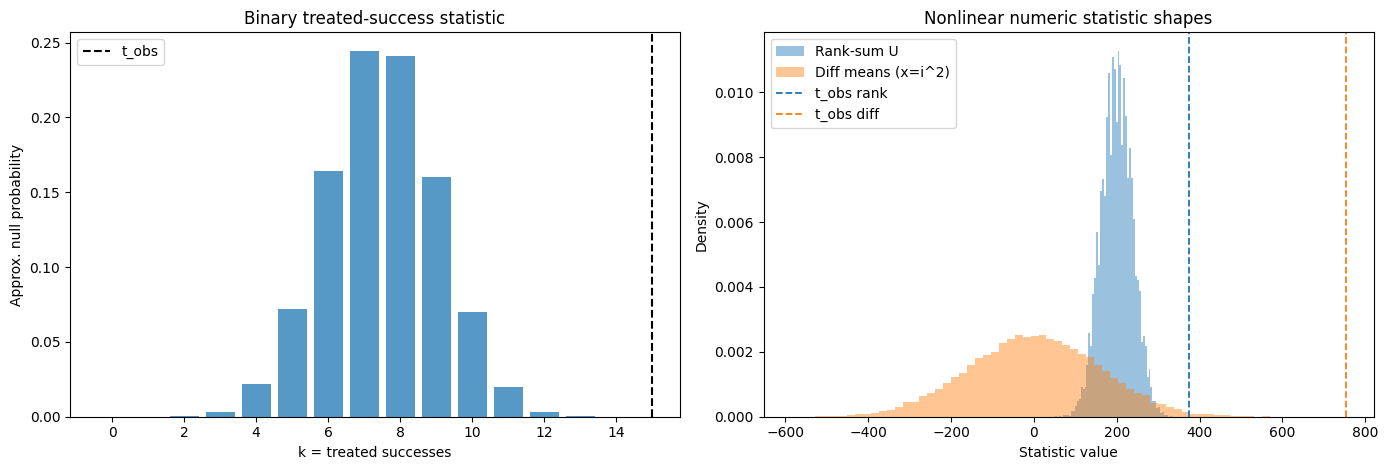

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Binary hypergeometric-like discrete distribution
k_vals = bin_t_uniform.astype(int)
max_k = int(np.max(k_vals))
counts = np.bincount(k_vals, minlength=max_k + 1)
probs = counts / np.sum(counts)
axes[0].bar(np.arange(max_k + 1), probs, alpha=0.75)
axes[0].axvline(bin_problem.t_obs, color="black", linestyle="--", linewidth=1.5, label="t_obs")
axes[0].set_title("Binary treated-success statistic")
axes[0].set_xlabel("k = treated successes")
axes[0].set_ylabel("Approx. null probability")
axes[0].legend()

# Nonlinear numeric: compare rank vs diff-in-means null shapes
axes[1].hist(nl_t_uniform_rank, bins=60, density=True, alpha=0.45, label="Rank-sum U")
axes[1].hist(nl_t_uniform_mean, bins=60, density=True, alpha=0.45, label="Diff means (x=i^2)")
axes[1].axvline(nl_problem_rank.t_obs, color="tab:blue", linestyle="--", linewidth=1.3, label="t_obs rank")
axes[1].axvline(nl_problem_mean.t_obs, color="tab:orange", linestyle="--", linewidth=1.3, label="t_obs diff")
axes[1].set_title("Nonlinear numeric statistic shapes")
axes[1].set_xlabel("Statistic value")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


## Repeated-run comparison (boxplots)

The next cell repeats the equal-budget experiment (`N_REPEATS` times) and draws boxplots for:
- estimator values (`log10` scale)
- estimated variances (`log10` scale)

Progress is printed after each repeat.

Variance sources:
- IID: analytic Bernoulli variance estimate from sampling SE
- MCMC-IS: OBM-based SNIS variance estimate
- SAMC: rough Bernoulli proxy `p_hat(1-p_hat)/n_eff` (coarse, dependence ignored)


[Rank-sum DP] repeat 1/4 done in 28.7s
[Rank-sum DP] repeat 2/4 done in 28.3s
[Rank-sum DP] repeat 3/4 done in 27.9s
[Rank-sum DP] repeat 4/4 done in 28.0s
[Rank-sum DP] total boxplot study time: 1.9 min


/var/folders/41/087q_7ns2kvc9g1r9zyhz2pw0000gp/T/ipykernel_79488/4250721770.py:243: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(est_log, labels=method_labels, showfliers=False)
/var/folders/41/087q_7ns2kvc9g1r9zyhz2pw0000gp/T/ipykernel_79488/4250721770.py:249: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(var_log, labels=method_labels, showfliers=False)


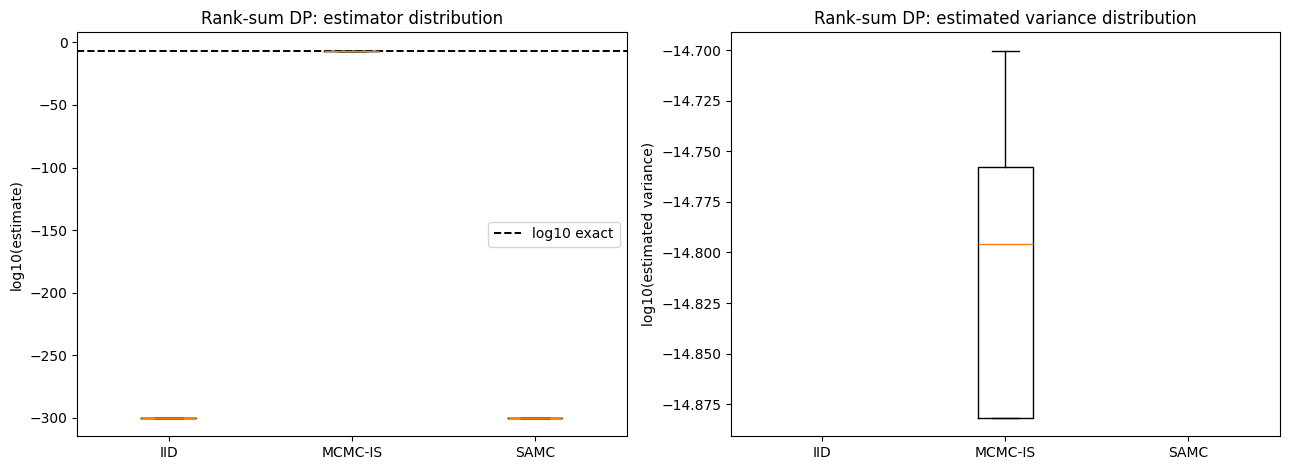

{
  "scenario": "Rank-sum DP",
  "exact_p": 8.445624347350904e-08,
  "equal_budget": {
    "iid_samples": 200000,
    "mcmc_total_steps": 200000,
    "samc_steps": 200000
  },
  "method_summary": {
    "IID": {
      "mean_estimate": 0.0,
      "median_estimate": 0.0,
      "std_estimate": 0.0,
      "mean_log10_estimate": -300.0
    },
    "MCMC-IS": {
      "mean_estimate": 1.5819291432946095e-07,
      "median_estimate": 1.4629856380393515e-07,
      "std_estimate": 4.090768051578181e-08,
      "mean_log10_estimate": -6.814603229431407
    },
    "SAMC": {
      "mean_estimate": 0.0,
      "median_estimate": 0.0,
      "std_estimate": 0.0,
      "mean_log10_estimate": -300.0
    }
  }
}


In [11]:
if BOXPLOT_SCENARIO == "rank":
    box_problem = rank_problem
    box_exact_p = rank_exact.p_value
    box_name = "Rank-sum DP"
elif BOXPLOT_SCENARIO == "linear":
    box_problem = lin_problem
    box_exact_p = lin_exact.p_value
    box_name = "Linear-stat DP"
else:
    raise ValueError("BOXPLOT_SCENARIO must be 'rank' or 'linear'.")

box_res = run_repeated_boxplot_study(
    box_problem,
    box_exact_p,
    scenario_name=box_name,
    seed_base=SEED_BOXPLOT_BASE,
    verbose=True,
)

print(json.dumps({
    "scenario": box_res["scenario"],
    "exact_p": box_res["exact_p"],
    "equal_budget": box_res["equal_budget"],
    "method_summary": box_res["method_summary"],
}, indent=2))


## MCMC-IS beta sweep diagnostics (feasible runtime)

This section compares diagnostics across multiple beta values while keeping runtime moderate.
It reports, per beta:
- `q_hat` under the tilted law (`P_{pi_beta}(T >= T_obs)`)
- `p_hat` estimate and error scale
- variance estimate of `p_hat` (OBM when enabled)
- ESS and acceptance rate


[beta sweep] mult=0.01 repeat 1/3 q=0.0000e+00 p_hat=0.0000e+00 ess=95836.6 acc=0.992
[beta sweep] mult=0.01 repeat 2/3 q=0.0000e+00 p_hat=0.0000e+00 ess=95832.1 acc=0.993
[beta sweep] mult=0.01 repeat 3/3 q=0.0000e+00 p_hat=0.0000e+00 ess=95834.9 acc=0.992
[beta sweep] mult=0.25 repeat 1/3 q=0.0000e+00 p_hat=0.0000e+00 ess=32077.7 acc=0.812
[beta sweep] mult=0.25 repeat 2/3 q=0.0000e+00 p_hat=0.0000e+00 ess=34458.1 acc=0.812
[beta sweep] mult=0.25 repeat 3/3 q=0.0000e+00 p_hat=0.0000e+00 ess=34188.9 acc=0.813
[beta sweep] mult=0.6 repeat 1/3 q=6.2500e-04 p_hat=1.3245e-07 ess=1522.2 acc=0.578
[beta sweep] mult=0.6 repeat 2/3 q=7.7083e-04 p_hat=1.5587e-07 ess=1897.0 acc=0.582
[beta sweep] mult=0.6 repeat 3/3 q=4.8958e-04 p_hat=4.9532e-08 ess=37.5 acc=0.581
[beta sweep] mult=0.85 repeat 1/3 q=3.4688e-03 p_hat=8.2106e-08 ess=55.3 acc=0.454
[beta sweep] mult=0.85 repeat 2/3 q=5.3125e-03 p_hat=1.0928e-07 ess=137.6 acc=0.450
[beta sweep] mult=0.85 repeat 3/3 q=4.2292e-03 p_hat=9.6113e-08 ess

/var/folders/41/087q_7ns2kvc9g1r9zyhz2pw0000gp/T/ipykernel_88710/4250721770.py:432: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(q_data, labels=labels, showfliers=False)
/var/folders/41/087q_7ns2kvc9g1r9zyhz2pw0000gp/T/ipykernel_88710/4250721770.py:437: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(est_log, labels=labels, showfliers=False)
/var/folders/41/087q_7ns2kvc9g1r9zyhz2pw0000gp/T/ipykernel_88710/4250721770.py:444: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(var_log, labels=labels, showfliers=False)
/var/folders/41/087q_7ns2kvc9g1r9zyhz2pw0000gp/T/ipyk

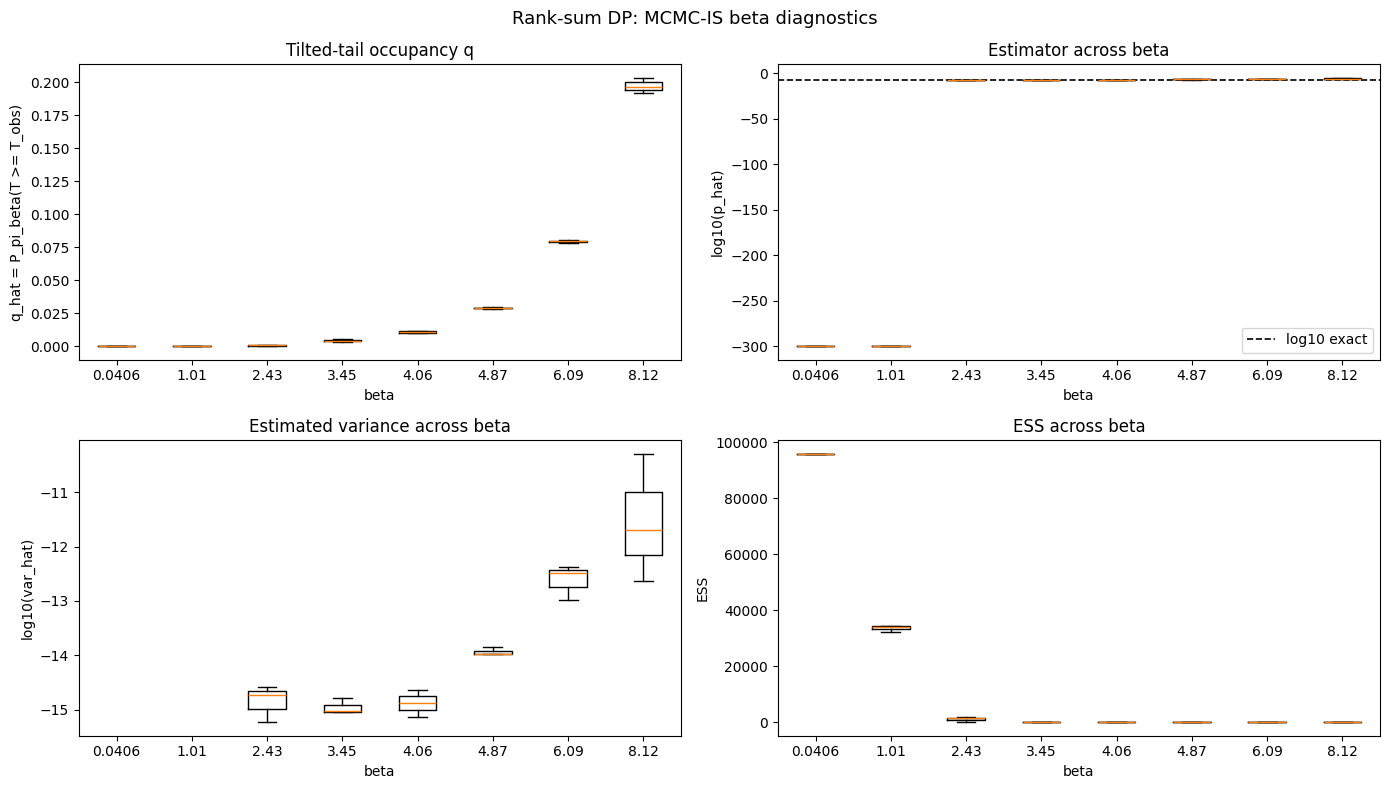

{
  "settings": {
    "total_steps": 120000,
    "steps_per_chain": 60000,
    "n_chains": 2,
    "burn_in": 12000,
    "thin": 1,
    "n_repeats": 3,
    "beta_center": 4.0576171875,
    "sigma_t": 36.46286052285344,
    "beta_multipliers": [
      0.01,
      0.25,
      0.6,
      0.85,
      1.0,
      1.2,
      1.5,
      2.0
    ]
  },
  "summary": [
    {
      "beta": 0.040576171875000004,
      "beta_multiplier": 0.01,
      "mean_q_tilt_tail_share": 0.0,
      "mean_estimate": 0.0,
      "std_estimate": 0.0,
      "mean_abs_log10_error": 292.92663176054845,
      "mean_variance_estimate": NaN,
      "mean_ess": 95834.54340563383,
      "mean_acceptance_rate": 0.9923972222222224
    },
    {
      "beta": 1.014404296875,
      "beta_multiplier": 0.25,
      "mean_q_tilt_tail_share": 0.0,
      "mean_estimate": 0.0,
      "std_estimate": 0.0,
      "mean_abs_log10_error": 292.92663176054845,
      "mean_variance_estimate": NaN,
      "mean_ess": 33574.9214168535,
      "mean_a

In [13]:
if BOXPLOT_SCENARIO == "rank":
    sweep_problem = rank_problem
    sweep_exact_p = rank_exact.p_value
    sweep_name = "Rank-sum DP"
    sweep_beta = rank_beta
elif BOXPLOT_SCENARIO == "linear":
    sweep_problem = lin_problem
    sweep_exact_p = lin_exact.p_value
    sweep_name = "Linear-stat DP"
    sweep_beta = lin_beta
else:
    raise ValueError("BOXPLOT_SCENARIO must be 'rank' or 'linear'.")

beta_sweep = run_beta_diagnostics_sweep(
    sweep_problem,
    sweep_exact_p,
    beta_center=sweep_beta["beta_used"],
    sigma_t=sweep_beta["sigma_t"],
    seed_base=SEED_BETA_SWEEP_BASE,
    beta_multipliers=BETA_SWEEP_MULTIPLIERS,
    n_repeats=BETA_SWEEP_REPEATS,
    total_steps=BETA_SWEEP_TOTAL_STEPS,
    n_chains=BETA_SWEEP_CHAINS,
    burn_in_frac=BETA_SWEEP_BURN_IN_FRAC,
    thin=BETA_SWEEP_THIN,
    estimate_variance=MCMC_ESTIMATE_VARIANCE,
    obm_batch_size=MCMC_OBM_BATCH_SIZE,
    verbose=True,
)

plot_beta_sweep_diagnostics(beta_sweep, sweep_exact_p, scenario_name=sweep_name)
print(json.dumps({
    "settings": beta_sweep["settings"],
    "summary": beta_sweep["summary"],
}, indent=2))


## Approximate Statistic Distribution Shapes

These histograms are from the single-run outputs above and help visualize the shape shift under MCMC tilt.


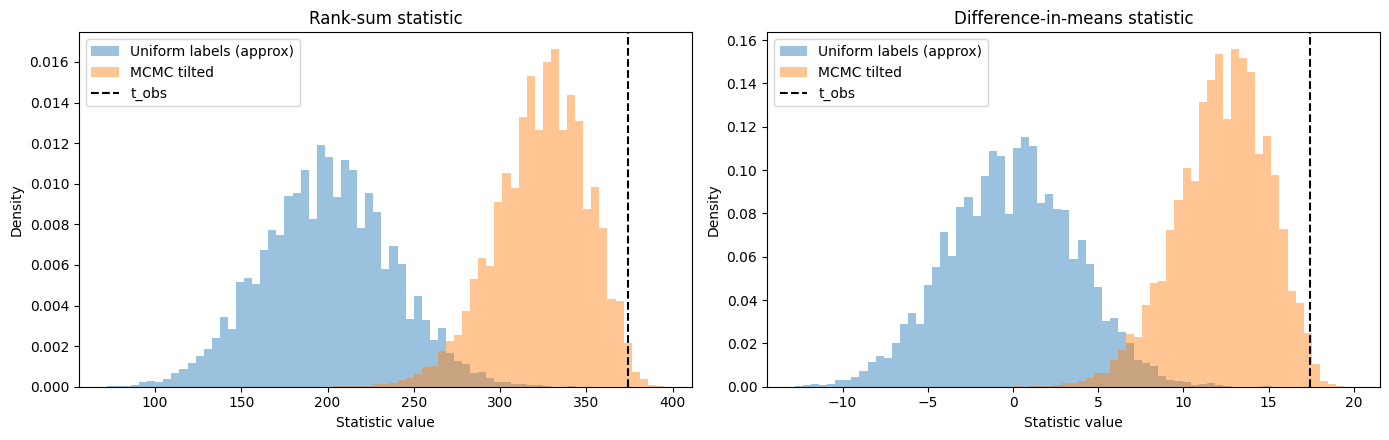

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

panels = [
    (axes[0], rank_t_uniform, rank_mcmc.t_samples, rank_problem.t_obs, "Rank-sum statistic"),
    (axes[1], lin_t_uniform, lin_mcmc.t_samples, lin_problem.t_obs, "Difference-in-means statistic"),
]

for ax, t_u, t_m, t_obs, title in panels:
    lo = float(min(np.min(t_u), np.min(t_m)))
    hi = float(max(np.max(t_u), np.max(t_m)))
    bins = np.linspace(lo, hi, 70)
    ax.hist(t_u, bins=bins, density=True, alpha=0.45, label="Uniform labels (approx)")
    ax.hist(t_m, bins=bins, density=True, alpha=0.45, label="MCMC tilted")
    ax.axvline(t_obs, color="black", linestyle="--", linewidth=1.5, label="t_obs")
    ax.set_title(title)
    ax.set_xlabel("Statistic value")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()
